# Medical Insurance Cost Prediction Using Machine Learning

## Project Information

### Dataset
- Dataset: Medical Cost Personal Dataset
- Source: Kaggle
- Original records: 1338
- Original columns: 7
- Final records after duplicate removal: 1337
- Final ML-ready columns: 9

### Input Features
- age
- sex
- bmi
- children
- smoker
- region_northwest
- region_southeast
- region_southwest

### Target Variable
- charges

### Machine Learning Type
- Regression

### Models Studied
1. Linear Regression
2. Decision Tree Regression

### Final Model
- Algorithm: Decision Tree Regression
- Maximum depth: 4
- Random state: 42

### Final Test Performance
- MAE: 2621.31
- MSE: 18886631.25
- RMSE: 4345.88
- R²: 0.8972

### Train/Test Split
- Training data: 1069 records
- Testing data: 268 records
- Test size: 20%

### Application
- Streamlit
- Saved model: models/insurance_model.pkl

### Example New Input
- Age: 40
- Sex: Male
- BMI: 28.5
- Children: 2
- Smoker: No
- Region: Northeast

### Example Prediction
- Predicted medical insurance charges: 7357.27

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
print("Sex:")
print(df["sex"].unique())

print("\nSmoker:")
print(df["smoker"].unique())

print("\nRegion:")
print(df["region"].unique())

Sex:
['female' 'male']

Smoker:
['yes' 'no']

Region:
['southwest' 'southeast' 'northwest' 'northeast']


In [13]:
print("Sex counts:")
print(df["sex"].value_counts())

print("\nSmoker counts:")
print(df["smoker"].value_counts())

print("\nRegion counts:")
print(df["region"].value_counts())

Sex counts:
sex
male      676
female    662
Name: count, dtype: int64

Smoker counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [14]:
df[df.duplicated()]


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [15]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(1337, 7)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows:
0


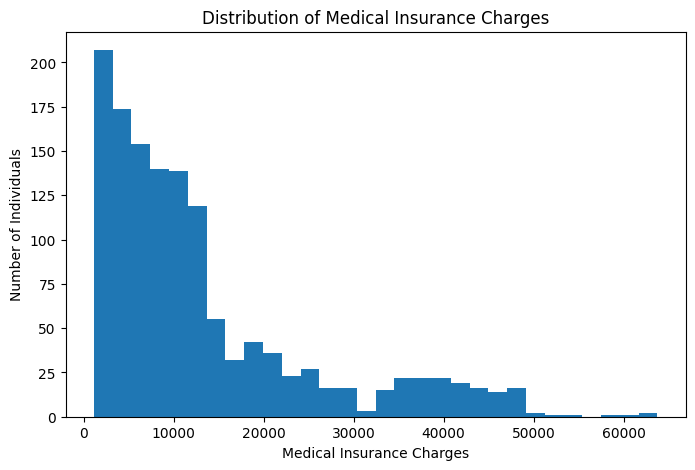

In [98]:
plt.figure(figsize=(8, 5))

plt.hist(df["charges"], bins=30)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Medical Insurance Charges")
plt.ylabel("Number of Individuals")

plt.savefig(
    "../visualizations/charges_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

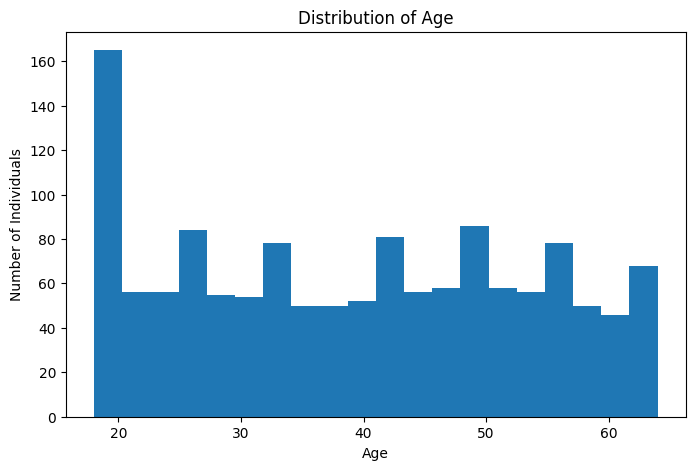

In [99]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=20)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

plt.savefig(
    "../visualizations/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

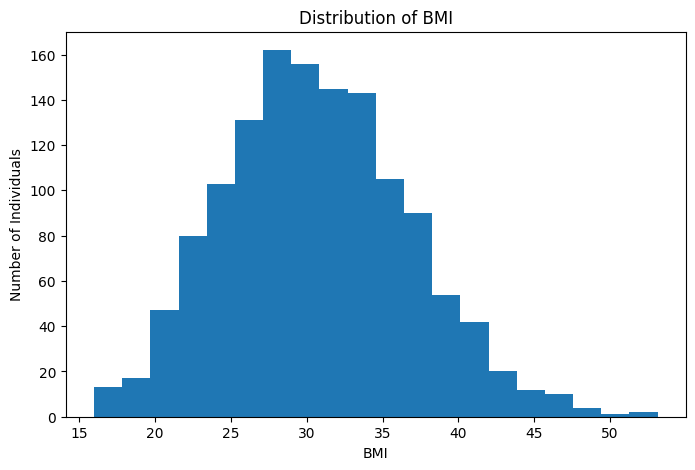

In [100]:
plt.figure(figsize=(8, 5))

plt.hist(df["bmi"], bins=20)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Individuals")

plt.savefig(
    "../visualizations/bmi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

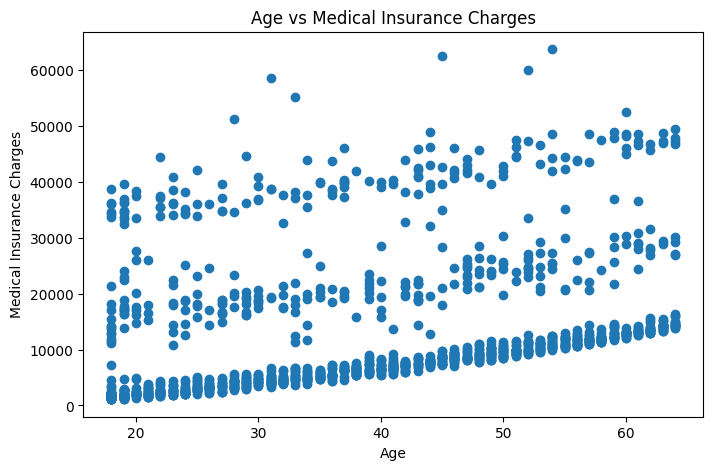

In [101]:
plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["charges"])

plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Medical Insurance Charges")

plt.savefig(
    "../visualizations/age_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

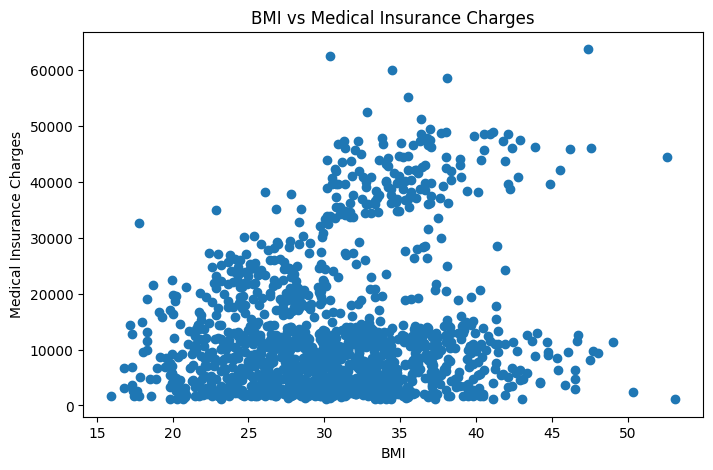

In [102]:
plt.figure(figsize=(8, 5))

plt.scatter(df["bmi"], df["charges"])

plt.title("BMI vs Medical Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Insurance Charges")

plt.savefig(
    "../visualizations/bmi_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
df.groupby("smoker")["charges"].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

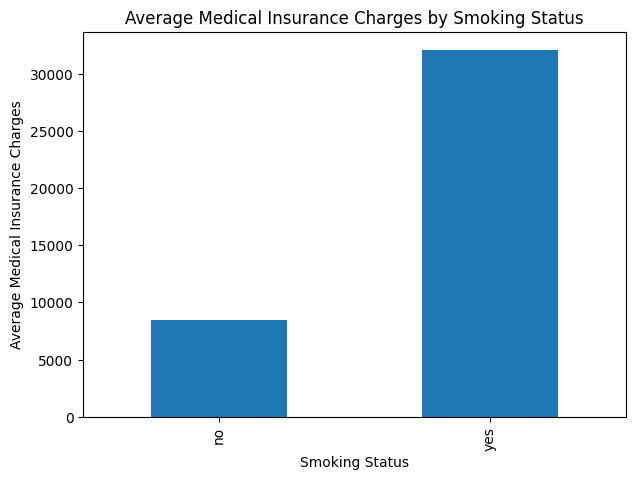

In [103]:
plt.figure(figsize=(7, 5))

df.groupby("smoker")["charges"].mean().plot(kind="bar")

plt.title("Average Medical Insurance Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Medical Insurance Charges")

plt.savefig(
    "../visualizations/smoker_vs_charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
correlation = df[["age", "bmi", "children", "charges"]].corr()

correlation

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


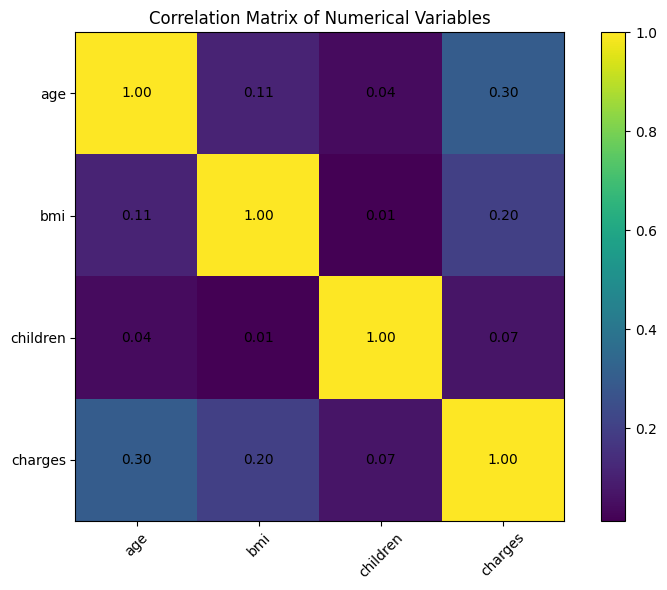

In [104]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

plt.savefig(
    "../visualizations/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
df_ml = df.copy()

In [40]:
df_ml["sex"] = df_ml["sex"].map({
    "male": 1,
    "female": 0
})

In [41]:
df_ml[["sex"]].head()

,sex
0,0
1,1
2,1
3,1
4,1


In [42]:
df_ml["smoker"] = df_ml["smoker"].map({
    "yes": 1,
    "no": 0
})

In [43]:
df_ml[["smoker"]].head()

,smoker
0,1
1,0
2,0
3,0
4,0


In [44]:
df_ml = pd.get_dummies(
    df_ml,
    columns=["region"],
    dtype=int,
    drop_first=True
)

In [45]:
df_ml.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [46]:
df_ml.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [47]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   int64  
 7   region_southeast  1337 non-null   int64  
 8   region_southwest  1337 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 104.5 KB


In [48]:
df_ml.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [49]:
X = df_ml.drop("charges", axis=1)

In [50]:
y = df_ml["charges"]

In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 8)
y shape: (1337,)


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


In [55]:
print("Original X rows:", len(X))
print("Train X rows:", len(X_train))
print("Test X rows:", len(X_test))

Original X rows: 1337
Train X rows: 1069
Test X rows: 268


In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
model = LinearRegression()

In [58]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
print("Intercept:", model.intercept_)
print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: -11092.652295945958

Coefficients:
age : 248.21072022470474
sex : -101.5420539902726
bmi : 318.70144095235037
children : 533.0099887986963
smoker : 23077.764592868094
region_northwest : -391.76145478360786
region_southeast : -838.9196157269599
region_southwest : -659.1397515529696


In [60]:
y_pred = model.predict(X_test)

In [61]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4177.045561036318


In [64]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 35478020.67523558


In [65]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5956.342894363585


In [66]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)


R²: 0.8069287081198013


In [67]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,4.177046e+03
1,MSE,3.547802e+07
2,RMSE,5.956343e+03
3,R²,8.069287e-01


In [68]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 4177.05
MSE  : 35478020.68
RMSE : 5956.34
R²   : 0.8069


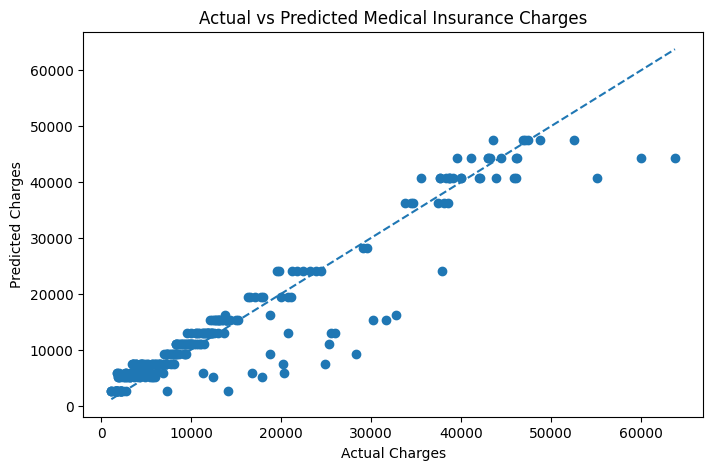

In [105]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, final_pred)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")

plt.savefig(
    "../visualizations/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
from sklearn.tree import DecisionTreeRegressor

In [72]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

In [73]:
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [74]:
tree_pred = tree_model.predict(X_test)

In [75]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print(f"Decision Tree MAE  : {tree_mae:.2f}")
print(f"Decision Tree MSE  : {tree_mse:.2f}")
print(f"Decision Tree RMSE : {tree_rmse:.2f}")
print(f"Decision Tree R²   : {tree_r2:.4f}")

Decision Tree MAE  : 2730.63
Decision Tree MSE  : 33281524.62
Decision Tree RMSE : 5769.01
Decision Tree R²   : 0.8189


In [76]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        mae,
        tree_mae
    ],
    "MSE": [
        mse,
        tree_mse
    ],
    "RMSE": [
        rmse,
        tree_rmse
    ],
    "R²": [
        r2,
        tree_r2
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
1,Decision Tree Regression,2730.629849,3.328152e+07,5769.014181,0.818882


In [77]:
tree_train_pred = tree_model.predict(X_train)

tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_pred))
tree_train_r2 = r2_score(y_train, tree_train_pred)

print(f"Training MAE  : {tree_train_mae:.2f}")
print(f"Training RMSE : {tree_train_rmse:.2f}")
print(f"Training R²   : {tree_train_r2:.4f}")

Training MAE  : 0.00
Training RMSE : 0.00
Training R²   : 1.0000


In [78]:
import joblib

In [79]:
joblib.dump(tree_model, "../models/insurance_model.pkl")

['../models/insurance_model.pkl']

In [80]:
new_person = pd.DataFrame({
    "age": [40],
    "sex": [1],
    "bmi": [28.5],
    "children": [2],
    "smoker": [0],
    "region_northwest": [0],
    "region_southeast": [0],
    "region_southwest": [0]
})

In [81]:
new_person

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,40,1,28.5,2,0,0,0,0


In [82]:
new_prediction = tree_model.predict(new_person)

print("Predicted Medical Insurance Charges:",
      new_prediction[0])

Predicted Medical Insurance Charges: 6600.361


In [83]:
depths = [2, 3, 4, 5, 6, 8, 10]

depth_results = []

for depth in depths:
    model_temp = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model_temp.fit(X_train, y_train)

    train_pred = model_temp.predict(X_train)
    test_pred = model_temp.predict(X_test)

    depth_results.append({
        "Max Depth": depth,
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,Max Depth,Train R²,Test R²,Test MAE,Test RMSE
0,2,0.813203,0.867202,3312.844898,4939.881196
1,3,0.844348,0.892951,2755.269509,4435.197024
2,4,0.855242,0.897219,2621.312405,4345.875200
3,5,0.866869,0.894090,2656.839079,4411.537636
4,6,0.885159,0.869880,2816.471629,4889.820469
5,8,0.933840,0.851467,2689.791608,5224.345045
6,10,0.979410,0.836279,2477.950758,5484.955996


In [84]:
final_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

In [85]:
final_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [86]:
final_pred = final_model.predict(X_test)

In [87]:
final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)

print(f"Final Model MAE  : {final_mae:.2f}")
print(f"Final Model MSE  : {final_mse:.2f}")
print(f"Final Model RMSE : {final_rmse:.2f}")
print(f"Final Model R²   : {final_r2:.4f}")

Final Model MAE  : 2621.31
Final Model MSE  : 18886631.25
Final Model RMSE : 4345.88
Final Model R²   : 0.8972


In [88]:
final_train_pred = final_model.predict(X_train)

final_train_mae = mean_absolute_error(y_train, final_train_pred)
final_train_rmse = np.sqrt(
    mean_squared_error(y_train, final_train_pred)
)
final_train_r2 = r2_score(y_train, final_train_pred)

print(f"Training MAE  : {final_train_mae:.2f}")
print(f"Training RMSE : {final_train_rmse:.2f}")
print(f"Training R²   : {final_train_r2:.4f}")

Training MAE  : 2567.47
Training RMSE : 4451.91
Training R²   : 0.8552


In [89]:
joblib.dump(
    final_model,
    "../models/insurance_model.pkl"
)

['../models/insurance_model.pkl']

In [90]:
loaded_model = joblib.load(
    "../models/insurance_model.pkl"
)

In [91]:
loaded_prediction = loaded_model.predict(X_test)

print(
    "Loaded model R²:",
    r2_score(y_test, loaded_prediction)
)

Loaded model R²: 0.8972190041804287


In [92]:
new_prediction = final_model.predict(new_person)

print(
    "Predicted Medical Insurance Charges:",
    new_prediction[0]
)

Predicted Medical Insurance Charges: 7357.271699545451


In [93]:
print(
    f"Predicted Medical Insurance Charges: "
    f"{new_prediction[0]:.2f}"
)

Predicted Medical Insurance Charges: 7357.27


In [94]:
def preprocess_input(age, sex, bmi, children, smoker, region):
    
    sex_encoded = 1 if sex == "male" else 0
    smoker_encoded = 1 if smoker == "yes" else 0
    
    region_northwest = 1 if region == "northwest" else 0
    region_southeast = 1 if region == "southeast" else 0
    region_southwest = 1 if region == "southwest" else 0
    
    input_data = pd.DataFrame({
        "age": [age],
        "sex": [sex_encoded],
        "bmi": [bmi],
        "children": [children],
        "smoker": [smoker_encoded],
        "region_northwest": [region_northwest],
        "region_southeast": [region_southeast],
        "region_southwest": [region_southwest]
    })
    
    return input_data

In [95]:
test_input = preprocess_input(
    40,
    "male",
    28.5,
    2,
    "no",
    "northeast"
)

test_input

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,40,1,28.5,2,0,0,0,0


In [96]:
test_input.equals(new_person)

True

In [97]:
test_prediction = final_model.predict(test_input)

print(
    f"Predicted Medical Insurance Charges: "
    f"{test_prediction[0]:.2f}"
)

Predicted Medical Insurance Charges: 7357.27


In [106]:
regions = ["northeast", "northwest", "southeast", "southwest"]

for region in regions:
    test_data = preprocess_input(
        40,
        "male",
        28.5,
        2,
        "no",
        region
    )

    prediction = final_model.predict(test_data)[0]

    print(f"{region:10} → {prediction:.2f}")

northeast  → 7357.27
northwest  → 7357.27
southeast  → 7357.27
southwest  → 7357.27


In [107]:
final_example = pd.DataFrame({
    "Age": [40],
    "Sex": ["Male"],
    "BMI": [28.5],
    "Children": [2],
    "Smoker": ["No"],
    "Region": ["Northeast"],
    "Predicted Charges": [new_prediction[0]]
})

final_example

,Age,Sex,BMI,Children,Smoker,Region,Predicted Charges
0,40,Male,28.5,2,No,Northeast,7357.2717


In [108]:
df_ml.to_csv(
    "../data/insurance_cleaned_encoded.csv",
    index=False
)

In [109]:
pd.read_csv(
    "../data/insurance_cleaned_encoded.csv"
).head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [110]:
pd.read_csv(
    "../data/insurance_cleaned_encoded.csv"
).shape

(1337, 9)

In [111]:
pd.read_csv(
    "../data/insurance_cleaned_encoded.csv"
).head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
